In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
merged_eu_27 = pd.read_csv("../data/raw/processed/eu_renewable_emissions.csv")
print(merged_eu_27.head())

  energia_ren pais  year  percentagem  mio_t_co2eq  meta_eu
0         REN   AT  2004       22.553     76.16585   19.947
1         REN   BE  2004        1.916    146.05407   40.584
2         REN   BG  2004        9.231     48.69074   33.269
3         REN   CY  2004        3.071      9.02067   39.429
4         REN   CZ  2004        6.773    139.10302   35.727


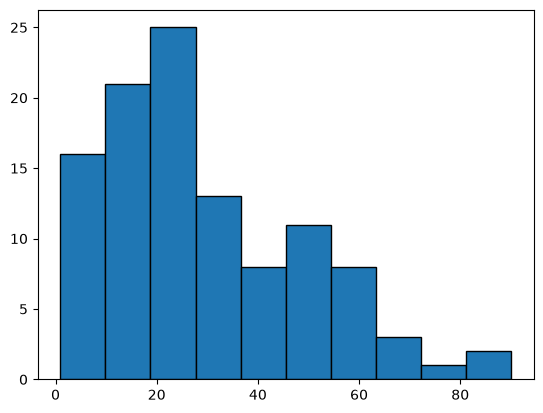

In [4]:
dados_2024 = merged_eu_27[merged_eu_27["year"] == 2024]

plt.hist(dados_2024["percentagem"], bins=10, edgecolor="black" )
plt.show()

Gráfico apresenta-se semelhante à distribuição de log-normal que dita que a maioria dos países está longe da meta 42,5% definida da EU. O que remete à separação de quem está em desenvolvimento para atingir a meta, de quem está está para lá dela.

In [5]:
dados_2024

,energia_ren,pais,year,percentagem,mio_t_co2eq,meta_eu
2160,REN,AT,2024,42.951,70.04211,-0.451
2161,REN,BE,2024,14.336,97.41448,28.164
2162,REN,BG,2024,23.210,35.43479,19.290
2163,REN,CY,2024,20.844,8.66536,21.656
2164,REN,CZ,2024,19.211,91.96670,23.289
...,...,...,...,...,...,...
2263,REN_TRA,PT,2024,14.329,52.14016,28.171
2264,REN_TRA,RO,2024,8.395,64.58247,34.105
2265,REN_TRA,SE,2024,26.399,-6.74422,16.101
2266,REN_TRA,SI,2024,9.242,11.03227,33.258


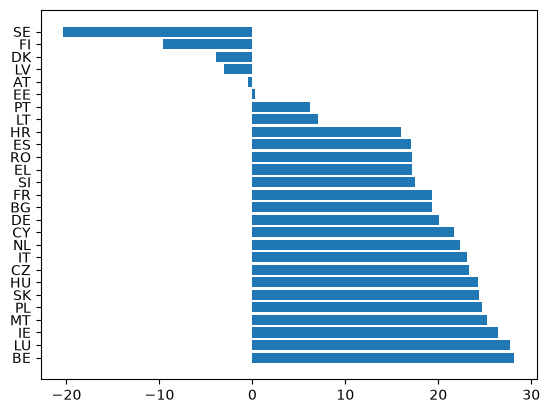

In [6]:
dados_2024 = dados_2024[dados_2024["energia_ren"] == "REN"]
dados_2024 = dados_2024.sort_values(by=["meta_eu"], ascending=False)
plt.barh(dados_2024["pais"], dados_2024["meta_eu"])
plt.show()

No caminho para atingir as metas definidas até 2030, países como Suécia, Finlândia, Dinamarca, Letónia e Áustria já lideram além do objetivo estabelecido, com a Estónia a poucos pontos percentuais de o alcançar. No caso de Portugal, conclui-se que o país se posiciona como um dos líderes na adoção de energias renováveis, estando a apenas 6.2 pontos percentuais da meta definida para 2030.

In [7]:
pt = merged_eu_27[merged_eu_27["pais"]=="PT"] 
energias = pt["energia_ren"].unique().tolist()

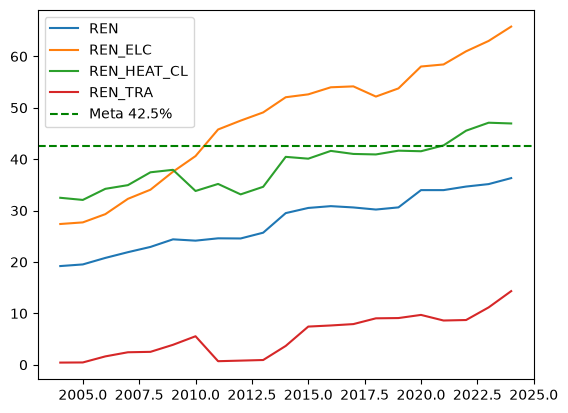

In [8]:
for col in energias:
    sub = pt[pt["energia_ren"] == col]
    plt.plot(sub["year"], sub["percentagem"], label=col)
plt.axhline(y=42.5, color="g", linestyle="--", label="Meta 42.5%")
plt.legend()

Ao analisar a evolução da quota de energia renovável (REN) em Portugal, verifica-se uma tendência geral de crescimento face à meta europeia de 42,5% definida para 2030.

Entre 2005 e 2010, registou-se um aumento de cerca de 5 pontos percentuais. Este crescimento foi interrompido entre 2010 e 2013, período em que as energias renováveis dedicadas aos transportes e à eletricidade sofreram um ligeiro decréscimo. A tendência de crescimento retomou entre 2013 e 2017 nas três áreas analisadas, seguida de nova estagnação até 2019.

A partir do período pós-pandémico, observa-se uma aceleração consistente da adoção de renováveis, particularmente nos setores de transportes e eletricidade, o que aproxima Portugal do cumprimento da meta europeia. É de notar que o setor elétrico (REN_ELC) já ultrapassou a meta de 42.5% desde 2013, sendo o setor de transportes (REN_TRA) o principal responsável pelo atraso do valor agregado face ao objetivo.

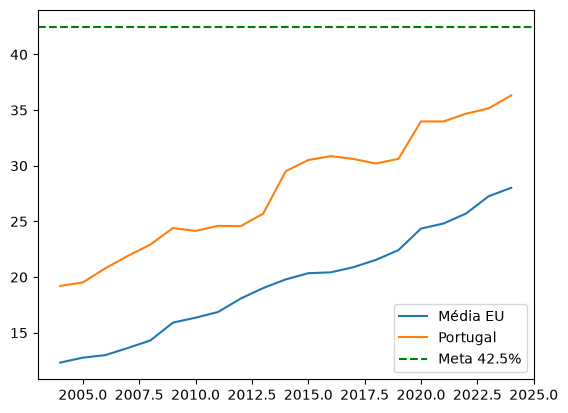

In [14]:
media_ren = merged_eu_27[merged_eu_27["energia_ren"]== "REN"]
media_ren = media_ren.groupby("year")["percentagem"].mean()
pt_eu = pt[pt["energia_ren"]=="REN"]


plt.plot(media_ren.index, media_ren.values, label="Média EU")
plt.plot(pt["year"], pt["percentagem"], label="Portugal")
plt.axhline(y=42.5, color="g", linestyle="--", label="Meta 42.5%")
plt.legend()
plt.show()

No caso deste gráfico, que compara a flutuações da média europeia perante a meta definida, com Portugal, é possível rapidamente identificar que Portugal sempre esteve sem no mínimo a 5 pontos percentuais superior à media, o que justifica o país ser uma das principais referências a nível de adoção de energias renováveis. A comparar as linhas, ambas apresentão flutuações semelhantes pelos diversos anos, menos no período de 2013 a 2017, onde Portugal teve um elevado crescimento nas adoção de energias renováveis, enquanto a média sofreu de um ligeiro decréscimo.